In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4090


In [2]:
#!pip install split-folders
import splitfolders
splitfolders.ratio('/mnt/d/FA019/new/Dataset', output='/mnt/d/FA019/new/SplittedDataset', seed=1337, ratio=(0.7, 0.1,0.2))

Copying files: 2309 files [00:41, 55.92 files/s]


Train: {'0': 352, '1': 341, '2': 324, '3': 309, '4': 288}
Validation: {'0': 50, '1': 48, '2': 46, '3': 44, '4': 41}
Test: {'0': 101, '1': 99, '2': 94, '3': 89, '4': 83}


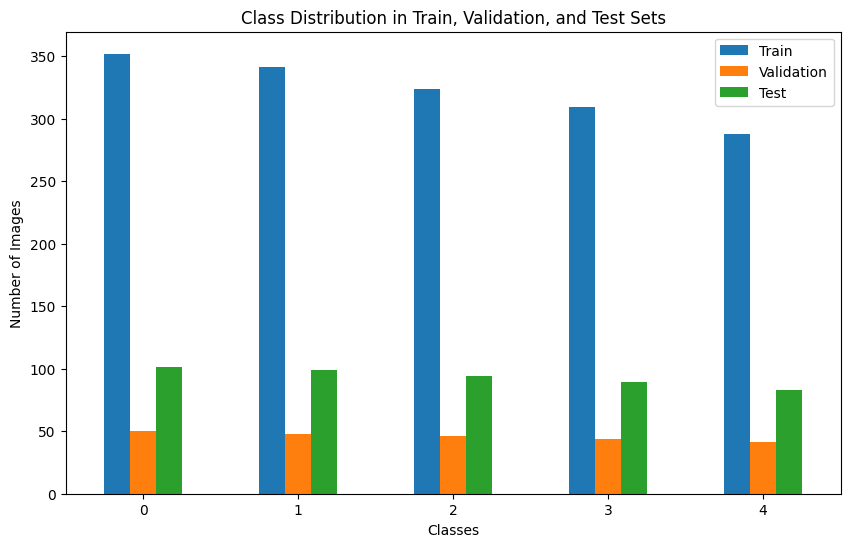

In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import pandas as pd

train_dir = '/mnt/d/FA019/new/SplittedDataset/train'
validation_dir = '/mnt/d/FA019/new/SplittedDataset/val'
test_dir = '/mnt/d/FA019/new/SplittedDataset/test'
classes = ['0', '1', '2', '3','4']

def count_images(directory):
    class_counts = {}
    for class_name in classes:
        class_path = os.path.join(directory, class_name)
        class_counts[class_name] = len(os.listdir(class_path))
    return class_counts

train_counts = count_images(train_dir)
validation_counts = count_images(validation_dir)
test_counts = count_images(test_dir)

print("Train:", train_counts)
print("Validation:", validation_counts)
print("Test:", test_counts)

# Combine counts into a DataFrame
data = {
    'Train': train_counts,
    'Validation': validation_counts,
    'Test': test_counts
}

df_counts = pd.DataFrame(data)

# Plot the class distribution
df_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Class Distribution in Train, Validation, and Test Sets')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)
plt.show()